In [1]:
pip install tensorflow keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1️⃣ Import libraries

In [2]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

2️⃣ Load cleaned dataset

In [3]:
import pandas as pd

df = pd.read_csv("C:\\Users\\sande\\Downloads\\pes\\sem 6\\vs code\\ml project\\sentiment-analysis-project\\notebooks\\data\\processed\\cleaned_reviews.csv")

print(df.shape)
df.head()



(23486, 2)


,final_text,sentiment
0,absolutely wonderful silky sexy comfortable,positive
1,love dress sooo pretty happened find store gla...,positive
2,high hope dress really wanted work initially o...,neutral
3,love love love jumpsuit fun flirty fabulous ev...,positive
4,shirt flattering due adjustable front tie perf...,positive


In [4]:
df["final_text"] = df["final_text"].fillna("")

3️⃣ Select features and labels

In [5]:
from sklearn.model_selection import train_test_split

X = df["final_text"]
y = df["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 18788
Test size: 4698


5️⃣ Tokenization (Text → numbers)

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
max_words = 10000
max_len = 200

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

#Convert text to sequences:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


print("Example review:")
print(X_train.iloc[0])

print("\nTokenized sequence:")
print(X_train_seq[0])

Example review:
dress fit well comfortable reflection hit mid shin rather appears model

Tokenized sequence:
[2, 3, 22, 28, 4279, 163, 448, 3200, 379, 503, 86]


7️⃣ Pad Sequences

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

#8️⃣ Encode Sentiment Labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Classes:", le.classes_)

Training shape: (18788, 200)
Testing shape: (4698, 200)
Classes: ['negative' 'neutral' 'positive']


9️⃣ Final Check   

In [8]:
print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)

print("y_train_encoded:", y_train_encoded.shape)
print("y_test_encoded:", y_test_encoded.shape)

X_train_pad: (18788, 200)
X_test_pad: (4698, 200)
y_train_encoded: (18788,)
y_test_encoded: (4698,)




 # **Stage 3.2 — LSTM Model**

In [9]:
#1️⃣ Import Deep Learning Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [10]:
#2️⃣ Define Model Architecture
model = Sequential([
    
    Embedding(
        input_dim=10000,   # vocabulary size
        output_dim=128,    # word embedding size
        input_length=200   # sequence length
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(3, activation="softmax")  # positive, neutral, negative
])

c:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
#3️⃣ Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.2533333333333334), 1: np.float64(2.726454796110869), 2: np.float64(0.4299510275069797)}


In [13]:
#4️⃣ Train Model
history = model.fit(

    X_train_pad,
    y_train_encoded,

    epochs=15,
    batch_size=128,

    validation_split=0.2,
    verbose=1
)

Epoch 1/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 46s 308ms/step - accuracy: 0.7709 - loss: 0.7286 - val_accuracy: 0.7829 - val_loss: 0.6760
Epoch 2/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 321ms/step - accuracy: 0.7734 - loss: 0.7071 - val_accuracy: 0.7829 - val_loss: 0.6754
Epoch 3/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 40s 340ms/step - accuracy: 0.7734 - loss: 0.7056 - val_accuracy: 0.7829 - val_loss: 0.6731
Epoch 4/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 39s 334ms/step - accuracy: 0.7734 - loss: 0.7054 - val_accuracy: 0.7829 - val_loss: 0.6726
Epoch 5/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 40s 339ms/step - accuracy: 0.7734 - loss: 0.7023 - val_accuracy: 0.7829 - val_loss: 0.6734
Epoch 6/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.7734 - loss: 0.7029 - val_accuracy: 0.7829 - val_loss: 0.6726
Epoch 7/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 83s 704ms/step - accuracy: 0.7734 - loss: 0.7004 - val_accuracy: 0.7829 - val_loss: 0.6746
Epoch 8/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 59s 414ms/step - accuracy: 0.7734 - loss: 0

In [15]:
#5️⃣ Evaluate Model
loss, accuracy = model.evaluate(X_test_pad, y_test_encoded)

print("Test Accuracy:", accuracy)

#6️⃣ Predictions
y_pred = model.predict(X_test_pad)

y_pred_classes = y_pred.argmax(axis=1)

#Convert predictions back to labels:

y_pred_labels = le.inverse_transform(y_pred_classes)

#7️⃣ Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_labels))

147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7752 - loss: 0.6884
Test Accuracy: 0.7752234935760498
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       482
     neutral       0.00      0.00      0.00       574
    positive       0.78      1.00      0.87      3642

    accuracy                           0.78      4698
   macro avg       0.26      0.33      0.29      4698
weighted avg       0.60      0.78      0.68      4698



c:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

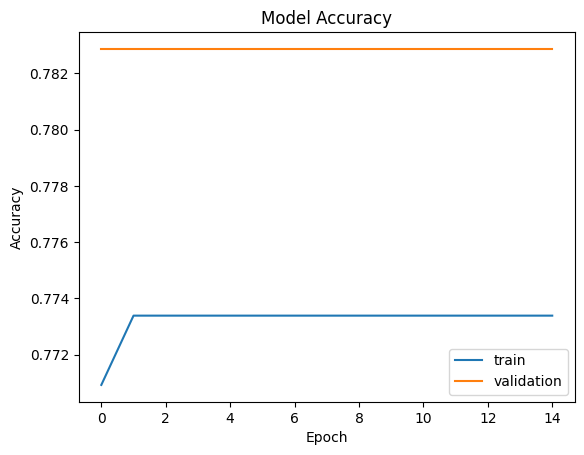

In [16]:
#8️⃣ Plot Training History
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()
